TensorFlow version: 2.20.0
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: 25000 | Test: 25000
Input shape: (25000, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 104s 318ms/step - accuracy: 0.6672 - loss: 0.5896 - val_accuracy: 0.7582 - val_loss: 0.5114
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 136s 300ms/step - accuracy: 0.8480 - loss: 0.3719 - val_accuracy: 0.8570 - val_loss: 0.3451
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 147s 316ms/step - accuracy: 0.9042 - loss: 0.2608 - val_accuracy: 0.8496 - val_loss: 0.3561
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 318ms/step - accuracy: 0.9290 - loss: 0.2017 - val_accuracy: 0.8664 - val_loss: 0.3749
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 136s 301ms/step - accuracy: 0.9429 - loss: 0.1634 - val_accuracy: 0.8472 - val_loss: 0.4133


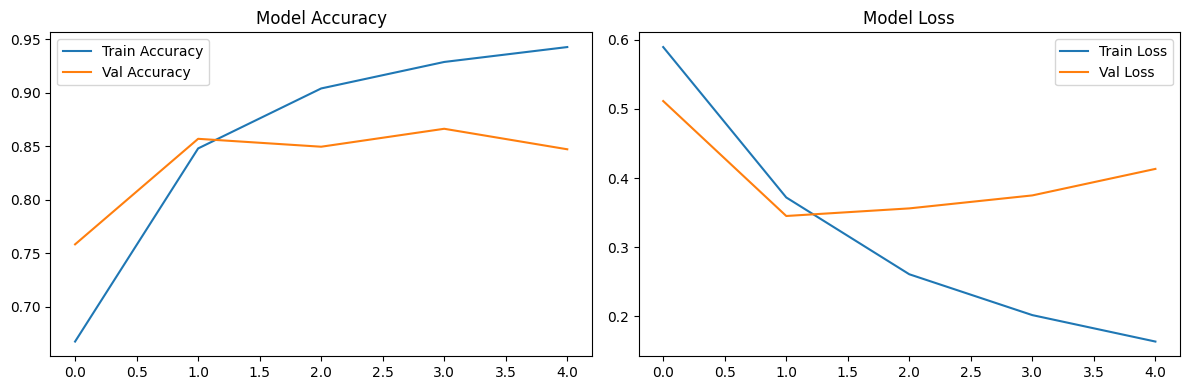


📊 Test Accuracy : 0.8326
   Test Loss    : 0.3748
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step

              precision    recall  f1-score   support

    Negative       0.85      0.81      0.83     12500
    Positive       0.82      0.86      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



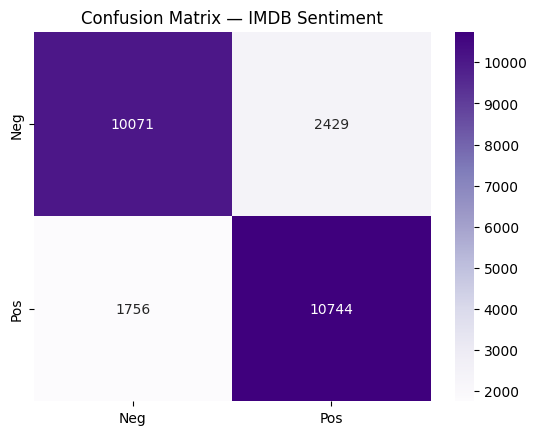


✅ Model saved as imdb_sentiment_model.h5
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  'This movie was absolutely brilliant and I loved every moment...' → POSITIVE 😊 (90.19%)
  'Terrible film, complete waste of time, very disappointing...' → NEGATIVE 😞 (4.09%)

✅ Task 2 complete!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense,
                                      Dropout, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")

# 1. Load IMDB dataset (top 10,000 words, built-in)
VOCAB_SIZE = 10000
MAX_LEN    = 200
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# 2. Pad sequences (tokenization done, just pad)
X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')
print(f"Input shape: {X_train.shape}")

# 3. Build model (transfer learning via pre-trained Embedding)
model = Sequential([
    Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# 4. Train with early stopping
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(X_train, y_train,
                    epochs=10, batch_size=64,
                    validation_split=0.2,
                    callbacks=[es], verbose=1)

# 5. Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('task2_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# 6. Evaluate on test set
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n📊 Test Accuracy : {acc:.4f}")
print(f"   Test Loss    : {loss:.4f}")

y_prob = model.predict(X_test).flatten()
y_pred = (y_prob > 0.5).astype(int)
print("\n" + classification_report(y_test, y_pred,
      target_names=['Negative','Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
plt.title('Confusion Matrix — IMDB Sentiment')
plt.savefig('task2_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

# 7. Save model
model.save('imdb_sentiment_model.h5')
print("\n✅ Model saved as imdb_sentiment_model.h5")

# 8. Inference example
word_index = imdb.get_word_index()
def predict_sentiment(review_text):
    words = review_text.lower().split()
    encoded = [word_index.get(w, 2)+3 for w in words]
    padded  = pad_sequences([encoded], maxlen=MAX_LEN, padding='post')
    prob    = model.predict(padded, verbose=0)[0][0]
    label   = "POSITIVE 😊" if prob > 0.5 else "NEGATIVE 😞"
    print(f"  '{review_text[:60]}...' → {label} ({prob:.2%})")

predict_sentiment("This movie was absolutely brilliant and I loved every moment")
predict_sentiment("Terrible film, complete waste of time, very disappointing")
print("\n✅ Task 2 complete!")